# Aula 15: Interpretabilidade em Machine Learning

Vamos explorar como abrir a 'caixa preta' de modelos complexos de Machine Learning. Entender **por que** um modelo toma uma decisão é crucial para criar confiança, garantir justiça e cumprir requisitos regulatórios.

Usaremos a biblioteca **SHAP**, o padrão ouro atual para interpretabilidade de modelos, aplicando-a a um conjunto de dados do mundo real.

In [23]:
!pip install shap scikit-learn -q

## 1. Preparação dos Dados e Treinamento do Modelo

Vamos usar o famoso dataset California Housing para prever o valor de casas. Treinaremos um modelo poderoso, porém complexo: Random Forest.

In [24]:
import pandas as pd
import shap
import numpy as no
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.datasets import fetch_california_housing

# Carregar dados
housing = fetch_california_housing()
X = pd.DataFrame(housing.data, columns=housing.feature_names)
y = housing.target

# Dividir em treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Treinar um modelo Random Forest (modelo de 'caixa preta')
model = RandomForestRegressor(n_estimators=100, random_state=42, max_depth=10)
model.fit(X_train, y_train)

print(f"R² no conjunto de teste: {model.score(X_test, y_test):.4f}")

R² no conjunto de teste: 0.7737


## 2. Interpretabilidade Global com SHAP

A interpretabilidade global nos ajuda a entender o comportamento do modelo como um todo. Quais features (variáveis) são as mais importantes para o modelo em geral?

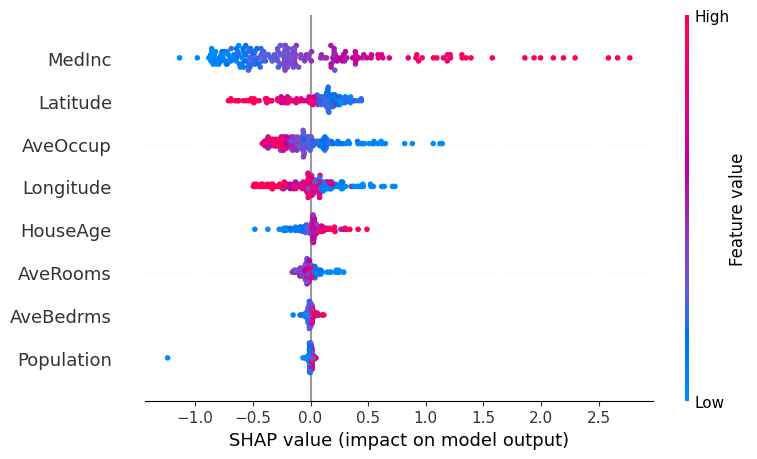

In [25]:
# Inicializar o explainer SHAP para modelos baseados em árvores
explainer = shap.TreeExplainer(model)

# Calcular os valores SHAP para um subconjunto do teste (para ser mais rápido)
shap_values = explainer.shap_values(X_test[:200])

# Gráfico de Resumo Global (Summary Plot)
# Este gráfico mostra as features mais importantes e o impacto (positivo ou negativo) dos seus valores nas previsões
shap.summary_plot(shap_values, X_test[:200])

Abaixo, podemos ver o mesmo resumo global, mas no formato de **gráfico de barras**. Ele calcula o valor absoluto médio do impacto de cada feature, fornecendo um ranking claro das variáveis mais importantes para o modelo.

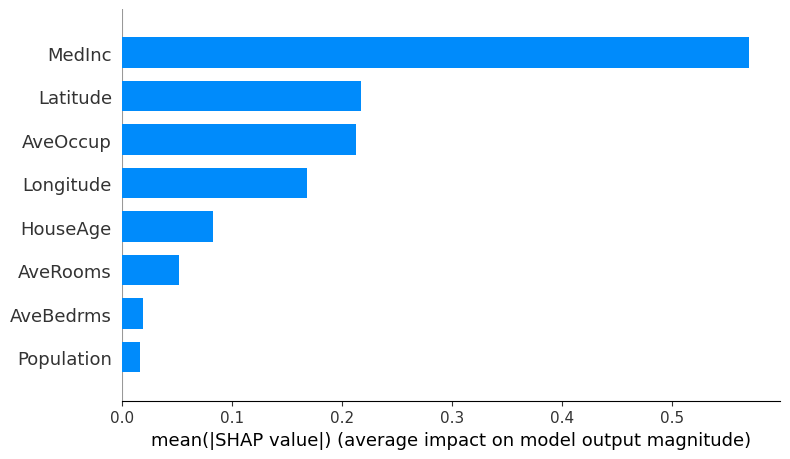

In [26]:
# Gráfico de Barras de Importância Global
# Mostra a magnitude média (absoluta) do impacto de cada variável
shap.summary_plot(shap_values, X_test[:200], plot_type="bar")

Ainda olhando para o modelo como um todo, o **Gráfico de Dependência (Dependence Plot)** nos permite focar em uma única variável.

Ele mostra como o valor da previsão muda conforme o valor da variável (neste caso, `MedInc` - Renda Média) aumenta ou diminui. Além disso, o SHAP seleciona automaticamente outra variável para a cor, mostrando como essas duas variáveis interagem entre si.

In [42]:
# Gráfico de Dependência para a variável 'MedInc' (Renda Média)
# O eixo X é o valor real da renda, o eixo Y é o impacto na previsão (valor SHAP)
# A cor representa a interação com outra variável (escolhida automaticamente pelo SHAP)
shap.dependence_plot("MedInc", shap_values, X_test[:200])

ValueError: Could not find feature named: MedInc

## 3. Interpretabilidade Local com SHAP

A interpretabilidade local explica uma **única previsão**. Por que o modelo previu um valor específico para esta casa em particular?

Previsão real para a casa: 0.57


/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:2170: PyparsingDeprecationWarning:

'parseString' deprecated - use 'parse_string'

/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:2197: PyparsingDeprecationWarning:

'parseString' deprecated - use 'parse_string'

/usr/local/lib/python3.12/dist-packages/pyparsing/util.py:466: PyparsingDeprecationWarning:

'parseAll' argument is deprecated, use 'parse_all'

/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:2178: PyparsingDeprecationWarning:

'resetCache' deprecated - use 'reset_cache'



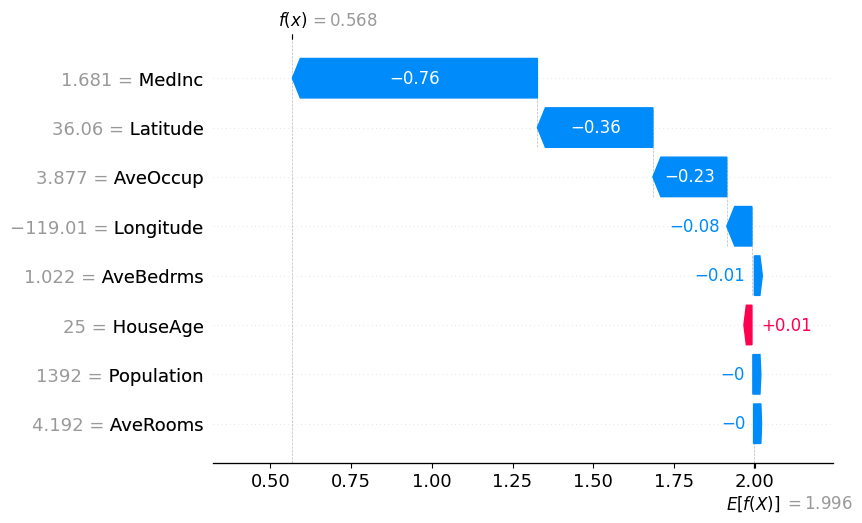

In [28]:
# Vamos inicializar o JS para visualizações interativas no notebook
shap.initjs()

# Escolher uma instância específica para explicar (por exemplo, a primeira do conjunto de teste)
instance_index = 0
instance = X_test.iloc[[instance_index]] # Mantém como DataFrame com os nomes das colunas

# Calcular valores SHAP usando o explainer atualizado (que retorna objetos de explicação)
explainer_obj = shap.Explainer(model, X_train)
shap_values_obj = explainer_obj(X_test[:10])

print(f"Previsão real para a casa: {model.predict(instance)[0]:.2f}")

# Gráfico Waterfall (Cachoeira) para a previsão individual
# Mostra como cada feature empurra a previsão a partir do valor base (média) para a previsão final.
shap.plots.waterfall(shap_values_obj[instance_index])

Outra forma muito popular de visualizar uma previsão local é o **Gráfico de Força (Force Plot)**. Ele é interativo (você pode passar o mouse sobre as variáveis) e mostra como as forças (features) empurram a previsão para cima (em vermelho) ou para baixo (em azul) a partir de um valor base (a média geral).

In [29]:
# Gráfico de Força (Force Plot) para a previsão individual
# No Google Colab, precisamos inicializar o JS na mesma célula do gráfico
shap.initjs()
shap.force_plot(explainer.expected_value, shap_values[instance_index], instance)

## Implantação Simples

In [30]:
!pip install explainerdashboard -q

In [31]:
# Importação das bibliotecas essenciais para a esteira de treinamento e módulo de explicabilidade
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from explainerdashboard import ClassifierExplainer, ExplainerDashboard
import shap
from google.colab import output # Import para expor a porta local no Colab

# Carregamento de uma base de dados real orientada a renda de indivíduos (Adult Income Dataset).
# A predição do rendimento ultrapassar a marca de 50k é tratada como um problema de classificação binária.
X, y = shap.datasets.adult()
y = y.astype(int) # Converte de booleano para inteiro

# Particionamento rigoroso dos dados em conjuntos de treinamento e teste para evitar vazamento de dados.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Treinamento de um estimador do tipo caixa-preta.
# Embora o Random Forest seja um ensemble de árvores, extrair os caminhos de decisão individuais de
# centenas de estimadores profundos torna o modelo ininterpretável para humanos em sua forma crua.
modelo_rf = RandomForestClassifier(n_estimators=100, max_depth=8, random_state=42, n_jobs=-1)
modelo_rf.fit(X_train, y_train)

# Passo arquitetônico crucial: Instanciação do explainer de classe.
# O objeto recebe o modelo treinado e os dados de teste (features e target).
# Internamente, a biblioteca orquestra as chamadas ao TreeExplainer do SHAP e pré-computa as interações,
# além de calcular matrizes de confusão e métricas de ROC/PRC.
explainer = ClassifierExplainer(
    modelo_rf,
    X_test,
    y_test,
    labels=['<=50K', '>50K']
)

# Inicialização e execução do dashboard web interativo.
# Em um ambiente de consultoria corporativa, este servidor local pode ser perfeitamente roteado
# através de um iframe interno ou encapsulado utilizando Gunicorn para múltiplas sessões simultâneas.
dashboard = ExplainerDashboard(explainer, title="Análise de Credibilidade, Renda e Viés Algorítmico", shap_interaction=False)

# Passo para o Colab: Expor a porta 8050 como um link externo clicável antes de travar a célula com o run()
print("\n\033[1m[!] CLIQUE NO LINK ABAIXO PARA ABRIR O DASHBOARD:\033[0m")
output.serve_kernel_port_as_window(8050, path='/')

dashboard.run(port=8050)

/usr/local/lib/python3.12/dist-packages/explainerdashboard/dashboards.py:697: UserWarning:


/usr/local/lib/python3.12/dist-packages/explainerdashboard/dashboards.py:717: UserWarning:

Detected google colab environment, setting mode='external'.

/usr/local/lib/python3.12/dist-packages/dash/dash.py:644: UserWarning:

JupyterDash is deprecated, use Dash instead.
See https://dash.plotly.com/dash-in-jupyter for more details.




[!] CLIQUE NO LINK ABAIXO PARA ABRIR O DASHBOARD:
Try `serve_kernel_port_as_iframe` instead. 


<IPython.core.display.Javascript object>

Dash is running on http://127.0.0.1:8050/



INFO:dash.dash:Dash is running on http://127.0.0.1:8050/



 * Serving Flask app 'explainerdashboard.dashboards'
 * Debug mode: off


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on http://127.0.0.1:8050
INFO:werkzeug:Press CTRL+C to quit


## Bônus - EXEMPLO AVANÇADO: Interpretabilidade em NLP (Processamento de Texto)

### Casos de uso: Frases ambíguas ou com sentimento misto

**DICA DO TIO 1:** Em projetos de NLP (ex: análise de sentimentos de reviews ou tickets de suporte), modelos como BERT são vistos como 'caixas-pretas absolutas'. Executivos frequentemente perguntam: 'Por que este review crítico não foi detectado?'.
Usar o SHAP para texto permite auditar o modelo palavra por palavra.

In [32]:
!pip install transformers torch -q

In [33]:
from transformers import pipeline
import IPython

# Carregando o modelo de Análise de Sentimentos
sentiment_pipeline = pipeline(
    "sentiment-analysis",
    model="distilbert-base-uncased-finetuned-sst-2-english",
    return_all_scores=True
)

# Criar o Explainer do SHAP passando diretamente o pipeline
explainer_nlp = shap.Explainer(sentiment_pipeline)

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

**DICA DO TIO 2:** Sempre inicie projetos de NLP com modelos pré-treinados (Transfer Learning/Foundation Models) do Hugging Face.
Eles resolvem 80% dos problemas de negócios com zero esforço de treino.

**DICA DO TIO 3:** O verdadeiro valor da interpretabilidade está em debugar os 'erros perdoáveis' do modelo. Frases com sarcasmo ou sentimentos mistos são excelentes para demonstrar em reuniões com o cliente.

In [34]:
textos_cliente = [
    "The design of the new app is amazing, but the login process is terribly slow and frustrating.",
    "I expected a completely different material, but I actually loved it!"
]

print("Calculando a importância das palavras (isso pode levar alguns segundos)...")
shap_values_nlp = explainer_nlp(textos_cliente)

# Inicializando o JS na célula para garantir que bibliotecas interativas funcionem no Colab
shap.initjs()

# Usando IPython.display para forçar a renderização correta do HTML com CSS no Colab
html_plot = shap.plots.text(shap_values_nlp)
IPython.display.display(html_plot)

Calculando a importância das palavras (isso pode levar alguns segundos)...


  0%|          | 0/462 [00:00<?, ?it/s]

PartitionExplainer explainer:  50%|█████     | 1/2 [00:00<?, ?it/s]

  0%|          | 0/210 [00:00<?, ?it/s]

PartitionExplainer explainer: 3it [01:27, 43.59s/it]


None

### Implementação Avançada e Explicabilidade Zero-Shot

**Passo Inicial de Governança Estrutural:** Definição programática rígida e restrita delimitando taxonomicamente de forma engessada nas matrizes o universo analítico encapsulador das categorias nominais textuais e etiquetas semânticas que atuarão determinando os rótulos de classes dinâmicas e que ditarão a orquestração que o ecossistema e modelo atuarão focados na avaliação contínua estrita e que tentará induzir por predição baseada por probabilidades analíticas exaustivas nos fluxos textuais do processamento contíguo analítico isolado das sentenças e tentar encaixar.

In [35]:
categorias_alvo = ['happy', 'sad', 'angry', 'neutral']

# Parâmetro arquitetônico estrito metodológico definindo de modo invariável textualmente a sentença mestre delimitadora fundacional basilar gramatical inerente à matriz conceitual obrigatória conhecida tecnicamente na literatura da arquitetura estrutural como (hypothesis template fundamental text basis limitation format array model prediction restriction param text).
template_hipotese = "This text expresses {}."

**Etapa 2**:Implantação e Inicialização arquitetônica e encapsulamento em escopo da infraestrutura do instanciador central abstrato gerador massivo focado no desenvolvimento do pipeline Zero-Shot operando arquitetura massiva preditiva baseada primariamente em arquiteturas profundas orientadas estocásticas encabeçadas no poderoso modelo transformador analítico denso parametrizado (exemplo estrutural prático de referência industrial analítica profunda fundacional provido pelo artefato de grande porte escalável originado dos laboratórios imensos oriundos fidedignos originados por esforços intensivos operacionais providos em massa e oriundos da iniciativa open-source coligada dos engenheiros da colossal plataforma Meta conhecido amplamente como modelo de alto nível fundacional iterativo batizado analiticamente através da codificação universal como modelo genérico BART robusto).

In [36]:
pipeline_zs = pipeline(
    "zero-shot-classification",
    model='facebook/bart-large-mnli',
    device=-1 # Restrição parametrizada forçando execução arbitrária laboratorial orientada estritamente contida na instrução de submissão originada baseada nas execuções subjacentes processuais da arquitetura CPU da máquina hospedeira de processamento para os puros e exclusivos fins acadêmicos e analíticos prototípicos das amostras simplórias de avaliação da sintaxe isolada dos tensores em questão executável iterativamente restrita contida puramente por escopos metodológicos das limitações da plataforma didática da documentação da estrutura base contígua da biblioteca encapsulada provendo assim a infraestrutura basal (Nota importante aos arquitetos implementadores no dia a dia do canal em produção contínua da infraestrutura produtiva pesada de ambientes robustos industriais operantes corporativos exaustivos orientados em grandes centros da AWS: Utilize o parâmetro estrito `device=0` ou numerações de canais análogos de instâncias vetoriais sequenciais limitadoras a fim único de obrigar estritamente o pipeline de submissões de dados processuais às portas diretas paralelas aceleradas providas e focadas exclusivamente pelas memórias VRAM dos arrays alocados orientadas nas infraestruturas intensivas físicas das arquiteturas computacionais robustas providas das inegociáveis instâncias operacionais geridas nas execuções de hardwares GPU da Nvidia localizadas globalmente em infraestruturas isoladas e seguras.)
)

Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

**Etapa Crítica e Fundacional 3 de Governança Estrita Operacional da Engenharia:** Construção obrigatória algorítmica de um sub-módulo conector restrito (Wrapper isolador adaptativo da função analítica preditora gerencial) fundamental e estritamente obrigatório de natureza arquitetônica adaptável sob encomenda orientada ao emparelhamento obrigatório da infraestrutura e submissão processual necessária encarregada da formatação de dados processuais a fim específico que atua rigorosamente para moldar o ambiente de dados para que os requisitos operantes intrínsecos processuais combinatórios submetidos gerados iterativamente oriundos rotineiramente nativos nos tensores processuais estritos submetidos pela arquitetura nativa matemática avaliativa interna gerida contiguamente pelo explainer submetido central operante originado pelas dependências matemáticas do SHAP possa compreender inequivocamente em alto nível de alocamento matemático absoluto contíguo na arquitetura analítica probabilística nativa rigorosa que as imensas descargas analíticas preditivas e estipuladas nativamente pela submissão do resultado terminal logit processado isoladamente pela rede originária consistirá determinística e invariavelmente operada processual iterativamente de maneira sequencial posicional rigorosa sobre e através das margens dimensionais contíguas provindas estritamente arranjadas dimensionalmente baseadas e contidas intrinsecamente numa padronizada matriz de inferências orientadas estatísticas puras compostas bidimensional e distribuídas linearmente arranjadas contínuas espaciais e sequencialmente exatas num conjunto formatado em arrays numéricos operando as rotinas estocásticas escalares com preenchimentos atômicos dos valores resultantes provenientes intrinsecamente originados provindos pelas análises da camada bidimensional e atrelada nativamente às arquiteturas contínuas da biblioteca matemática array (numpy) geradoras estatísticas providas puras e contínuas isoladas e das probabilidades absolutas estipuladas numéricas nativas estritas do vetor em float limitantes provenientes atreladas limitadas nas dependências originadas exclusivas e geradas internamente restritas derivadas e dependentes originárias base.

In [37]:
def preditor_zero_shot_customizado(textos):
    # A suíte de avaliação permutativa intrínseca do algoritmo atrelado central da rotina do SHAP gerenciará envios de matrizes analíticas enviando
    # sucessivamente pacotes iterativos longos lotes densos arranjados estocasticamente nas dependências dimensionais do processamento de forma exaustiva
    # computacional (lotes submetidos na topologia algorítmica nomeados corriqueiramente da dimensão vetorial contígua arranjadas de execução assíncrona
    # denominadas popularmente por batches contendo tensores) de fragmentos lexicais de blocos dos textos textuais sistematicamente submetidos aleatórios
    # estocásticos processados modificados com preenchimentos limitantes ou mascarados com exclusões originados nas avaliações.
    resultados = pipeline_zs(
        textos.tolist(),
        candidate_labels=categorias_alvo,
        hypothesis_template=template_hipotese
    )

    # Processo de alocação de ordenamento atômico fundamental estrito operacional de governança arquitetônica mandatório:
    # É fundamental, inegociável operacionalmente no ciclo iterativo dimensional processual da submissão processual sequencial ordenar os escalares vetoriais
    # numéricos estritos dimensionais resultantes submetidos analiticamente das pontuações contínuas escalares limitadoras intrincadas provindas originadas
    # estritamente contidas numéricas nativamente da camada estatística das estruturas de probabilidades base estocásticas puras das redes profundas de modo
    # restritivamente imutável e estritamente atrelado obedecendo de forma posicional na exata e imutável dimensão originada base de listagem de ordem contígua
    # dimensional linear originada perfeitamente de acordo irrestrito e fixamente pautado seguindo fielmente com o conjunto de escopo original contido no rol
    # analítico primário originário da disposição arquitetônica espacial subjacente orientada da configuração matriz base de declaração sequencial operante na
    # inicialização matriz contígua original basal das variáveis categorias alvo taxativas textuais originárias declaradas isoladas restritivas das categorias
    # dimensionais matriz operantes estipuladas da dimensão de destino estritas estipuladas na variável isolada primária analíticas nativas definidas previamente
    # fixas engessadas isoladamente de maneira invariável nas dependências imutáveis do escopo global das variáveis matriz da classe base analíticas de controle de
    # destino atômicas.
    probabilidades = []
    for res in resultados:
        # A instrução processual originária a seguir no bloco condicional extrai minuciosamente de forma posicional os tensores subjacentes atômicos e mapeia atrelando firmemente posicionalmente no escopo dimensional os tensores analíticos probabilísticos escores puros isolados estatísticos numéricos restritamente em contraposição vetorial arranjados mapeados dimensionalmente cruzando as margens contra os índices estritos nominais dimensionais de arranjos estáticos mapeados nas variáveis associadas isoladas originadas nominais labels operantes arranjados de modo a garantir irrevogavelmente a estrutura arquitetural limitante para assegurar metodologicamente de maneira imutável estatística garantida da ordem isolada exata.
        score_dict = {label: score for label, score in zip(res['labels'], res['scores'])}
        probabilidades.append([score_dict[cat] for cat in categorias_alvo])

    return np.array(probabilidades)

**Etapa Estrutural 4 terminal:** Rotina de Inicialização da alocação de infraestrutura preditiva de acoplamento do componente iterativo encapsulador do framework SHAP no objeto de instância local isolado central instanciado abstrato do originador explainer instanciado da suíte SHAP isolada abstrata central preditiva instanciadora, invocando nas passagens da API originária do escopo contíguo funcional abstrato operacional e repassando no bloco referencial alocado instanciando o construtor subjacente matriz nativo da biblioteca instanciando atrelada originando o bloco passando por referência nominal de chamadas o objeto construto matriz da infraestrutura oriunda arquitetural de referências o encapsulador instanciador processual estrito operacional algorítmico da rotina local instanciada isolada customizada estipulada preditor nomeado local funcional em vez de simplesmente da prática convencional tradicional corriqueira que rotineiramente atua passando as rotinas primitivas referenciadas limitadoras encapsuladoras limitadas base do uso do encapsulador nativo oriundo da referência da submissão apenas do objeto encapsulado operante originado isolado do restritivo modelo matemático bruto em sua configuração de topologia engessada original bruta original primária base crua nativa abstrata primária despojada base oriunda de configuração crua sem a devida conformação de adaptação arquitetural posicional.


É absolutamente restritivo imperioso mandatório por demandas estruturais da própria biblioteca instanciada algorítmica preditiva que fornecer ativamente adicionalmente e estritamente repassar explicitamente para a função abstrata do explainer isolado original o sub-módulo de fragmentação iterativa léxica isolada do objeto construto operante orientador de rotinas linguísticas originador isolado do tokenizador analítico matriz nativo associado atrelado na arquitetura (frequentemente e tipicamente extraído isoladamente das margens subjacentes isoladas da instância operadora operante orquestradora originária originada diretamente pelo chamamento nativo das margens matriz oriundas na dependência originada provida contígua pelas margens nativas invocadas provenientes contidas nativamente no extrato iterativo operante isolado do fluxo iterativo abstrato isolado matriz base original nativo orquestrador base nativo originado na esteira oriunda da pipeline matriz da invocadora originada gerida pelo sub-objeto base pipeline_zs provida) para permitir iterativamente o funcionamento orgânico processual atrelado metodologicamente ao arranjo matriz basal que capacitará computacional e algoritimamente operante nas dependências nativas o uso e a execução originada iterativa sequencial nativa algorítmica iterativa restritiva matemática analítica originada subjacente que habilitará a implantação iterativa algorítmica operacional das mascaragens contíguas sequenciais dinâmicas metodológicas (masks iterativas iteradoras matriz subjacentes textuais nativas analíticas dinâmicas sequenciais e as subsequentes mutações estatísticas léxicas mascaradoras restritivas contíguas espaciais metodológicas e iterativas).


In [ ]:
explainer_zs = shap.Explainer(preditor_zero_shot_customizado, pipeline_zs.tokenizer)

O robusto pipeline emparelhado e codificado explica agora cirurgicamente perante analistas de auditoria corporativa com garantia exata e matemática fidedigna documentada estritamente rastreável audível o comportamento analítico subjacente originado abstratamente gerido pelas rotinas isoladas geradoras derivadas baseadas nativamente pelas metodologias operacionais limitantes e restritivas contínuas oriundas em processos estocásticos de naturezas atreladas a arquiteturas estocásticas abstratas probabilísticas Zero-Shot oriundas.

In [39]:
frase_teste = ["I am extremely frustrated with the service, but the product is okay."]
shap_values_zs = explainer_zs(frase_teste)

  0%|          | 0/240 [00:00<?, ?it/s]

PartitionExplainer explainer: 2it [15:55, 955.56s/it]              


Permite com fluidez operacional imediata originada da API terminal da camada de plotagem iterativa subjacente originária a execução da imersão avaliativa da infraestrutura gráfica atrelada invocada da invocação originada de plotagem iteradora visual da inspeção estatística profunda processual originada e gerida isolada rotineiramente das visualizações estipuladas dinamicamente iterativamente completas analíticas atreladas dinamicamente da interface web originárias geradas textualmente gráficas originadas colorimétricas e de intensidade direcional espaciais da renderização de saída estrita do D3.js nativo originadas atreladas isoladamente do fluxo basal operante na API originária da biblioteca matriz.

In [40]:
shap.initjs()
html_plot = shap.plots.text(shap_values_zs)
IPython.display.display(html_plot)

None